In [1]:
import timm

print("timm version:", timm.__version__)

timm version: 1.0.28


In [2]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
detector = pipeline(
    task="object-detection",
    model="facebook/detr-resnet-50"
)

print("Model loaded successfully!")

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

c:\Work\mini_adas_vision\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rushi\.cache\huggingface\hub\models--facebook--detr-resnet-50. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Model loaded successfully!


In [4]:
from PIL import Image

image = Image.open("../images/road.jpg")

print("Image loaded successfully")
print("Image size:", image.size)
print("Image mode:", image.mode)

Image loaded successfully
Image size: (500, 334)
Image mode: RGB


<function matplotlib.pyplot.show(close=None, block=None)>

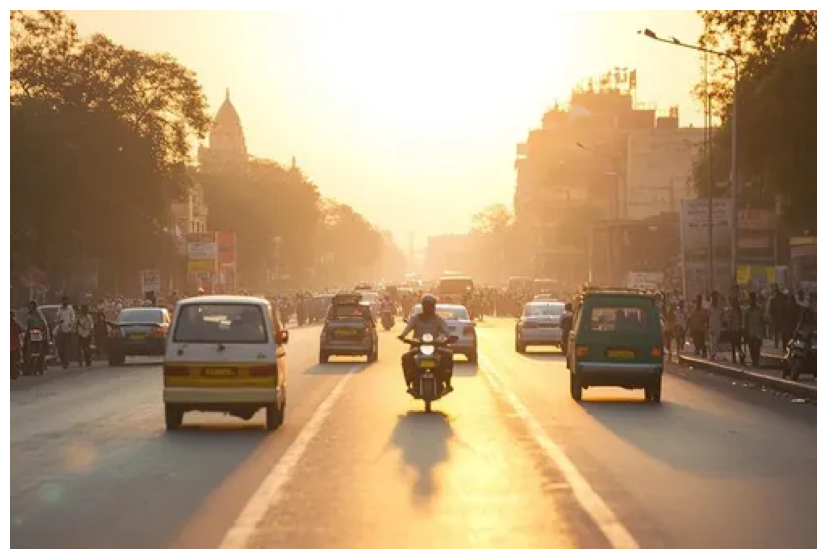

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plt.imshow(image)
plt.axis("off")
plt.show

In [7]:
results = detector(image)

print("Number of detections:", len(results))
print()

for i, result in enumerate(results, start=1):
    print(f"Detection #{i}")
    print(f"    Label :  {result['label']}")
    print(f"    Score : {result['score']:.4f}")
    print(f"    Box   : {result['box']}")
    print()

Number of detections: 50

Detection #1
    Label :  person
    Score : 0.5496
    Box   : {'xmin': 243, 'ymin': 176, 'xmax': 251, 'ymax': 192}

Detection #2
    Label :  car
    Score : 0.6830
    Box   : {'xmin': 222, 'ymin': 171, 'xmax': 233, 'ymax': 179}

Detection #3
    Label :  person
    Score : 0.7110
    Box   : {'xmin': 237, 'ymin': 176, 'xmax': 246, 'ymax': 196}

Detection #4
    Label :  person
    Score : 0.8095
    Box   : {'xmin': 419, 'ymin': 178, 'xmax': 432, 'ymax': 216}

Detection #5
    Label :  person
    Score : 0.5591
    Box   : {'xmin': 39, 'ymin': 173, 'xmax': 54, 'ymax': 221}

Detection #6
    Label :  person
    Score : 0.7683
    Box   : {'xmin': 409, 'ymin': 178, 'xmax': 422, 'ymax': 215}

Detection #7
    Label :  truck
    Score : 0.7127
    Box   : {'xmin': 344, 'ymin': 171, 'xmax': 406, 'ymax': 243}

Detection #8
    Label :  person
    Score : 0.6538
    Box   : {'xmin': 404, 'ymin': 178, 'xmax': 416, 'ymax': 214}

Detection #9
    Label :  car
    Sc

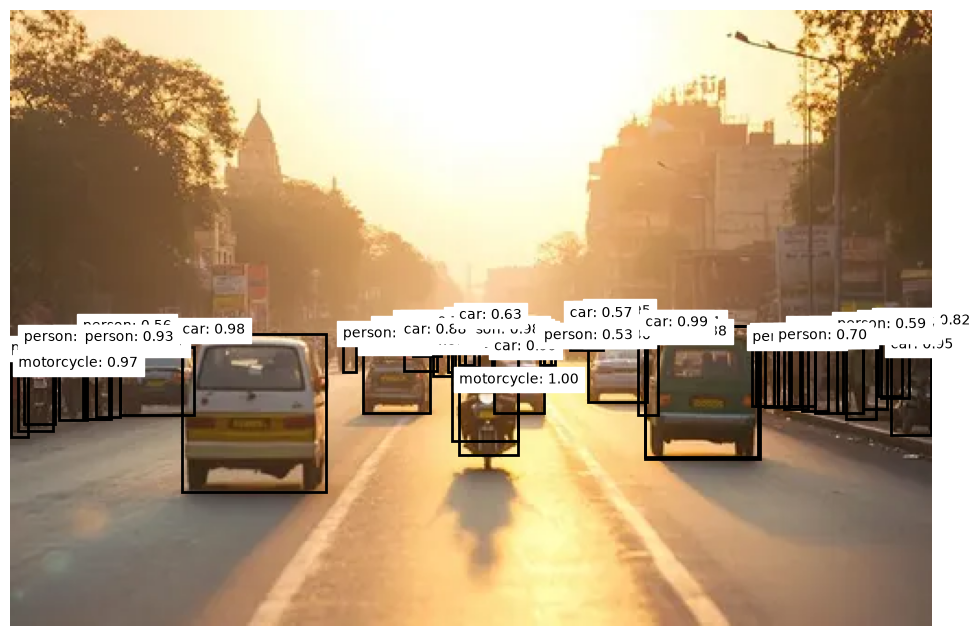

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 8))

ax.imshow(image)

for result in results:
    score = result["score"]
    label = result["label"]
    box = result["box"]

    xmin = box["xmin"]
    ymin = box["ymin"]
    xmax = box["xmax"]
    ymax = box["ymax"]

    width = xmax - xmin
    height = ymax - ymin

    rectangle = Rectangle(
        (xmin, ymin),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.text(
        xmin,
        ymin,
        f"{label}: {score:.2f}",
        fontsize=10,
        backgroundcolor="white"
    )

ax.axis("off")
plt.show()

In [9]:
CONFIDENCE_THRESHOLD = 0.70

filtered_results = [
    result
    for result in results
    if result["score"] >= CONFIDENCE_THRESHOLD
]

print("Original detections :", len(results))
print("Filtered detections :", len(filtered_results))

print("\nRemaining detections:")

for result in filtered_results:
    print(
        f"{result['label']:12s} "
        f"{result['score']:.2%}"
    )

Original detections : 50
Filtered detections : 35

Remaining detections:
person       71.10%
person       80.95%
person       76.83%
truck        71.27%
car          94.74%
person       76.49%
car          70.51%
person       86.29%
motorcycle   81.76%
person       84.10%
car          71.91%
person       81.93%
person       78.10%
car          99.69%
person       96.21%
person       94.50%
car          94.55%
car          94.54%
person       70.09%
car          99.14%
person       92.89%
car          98.12%
person       80.53%
person       82.33%
person       97.93%
person       88.03%
person       92.90%
motorcycle   96.80%
car          74.53%
person       97.46%
car          88.01%
car          99.21%
car          99.58%
motorcycle   99.70%
car          99.43%


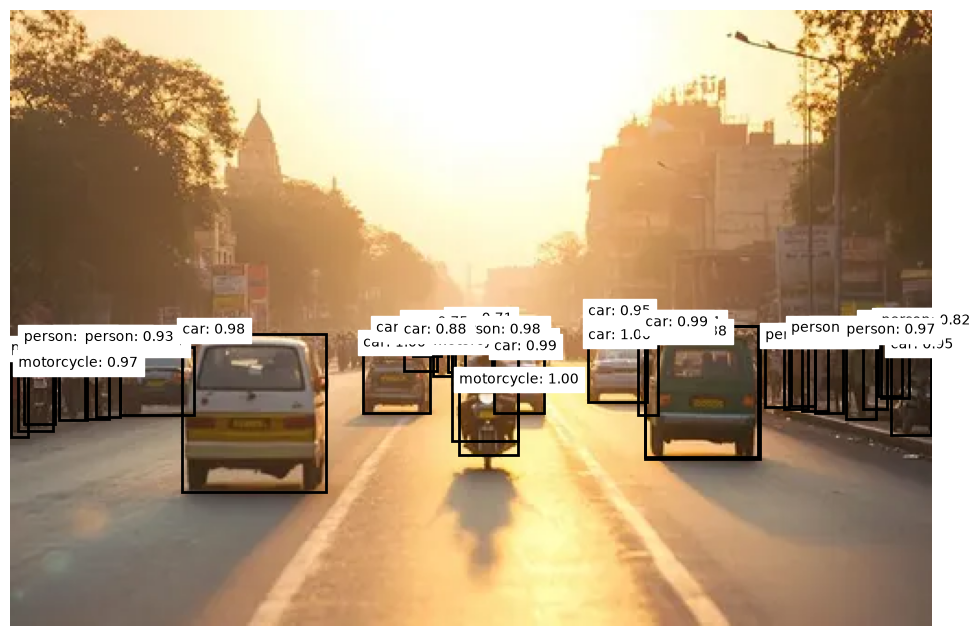

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 8))

ax.imshow(image)

for result in filtered_results:
    score = result["score"]
    label = result["label"]
    box = result["box"]

    xmin = box["xmin"]
    ymin = box["ymin"]
    xmax = box["xmax"]
    ymax = box["ymax"]

    width = xmax - xmin
    height = ymax - ymin

    rectangle = Rectangle(
        (xmin, ymin),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.text(
        xmin,
        ymin,
        f"{label}: {score:.2f}",
        fontsize=10,
        backgroundcolor="white"
    )

ax.axis("off")
plt.show()

In [11]:
from collections import Counter

object_counts = Counter(
    result["label"]
    for result in filtered_results
)

print("Detected objects")
print("----------------")

for label, count in object_counts.items():
    print(f"{label:15s}: {count}")

Detected objects
----------------
person         : 18
truck          : 1
car            : 13
motorcycle     : 3


In [14]:
def analyze_road_scene(object_counts):
    analysis = []

    vehicle_types = [
        "car",
        "truck",
        "bus",
        "motorcycle"
    ]

    vehicle_count = sum(
        object_counts.get(vehicle, 0)
        for vehicle in vehicle_types
    )

    pedestrain_count = object_counts.get("person", 0)

    analysis.append(
        f"Vehicles detected: {vehicle_count}"
    )

    analysis.append(
        f"Pedestrains detected: {pedestrain_count}"
    )

    if pedestrain_count > 0:
        analysis.append(
            "⚠️ Pedestrian detected"
        )

    if vehicle_count >= 5:
        analysis.append(
            "⚠️ Heavy traffic detected"
        ) 
    else:
        analysis.append(
            "✅ Traffic level appears normal"
        )

    return analysis

In [15]:
analysis = analyze_road_scene(object_counts)

print("ADAS Analysis")
print("-------------")

for item in analysis:
    print(item)

ADAS Analysis
-------------
Vehicles detected: 17
Pedestrains detected: 18
⚠️ Pedestrian detected
⚠️ Heavy traffic detected
